# Clasificación de tweets nuevos

Construimos la función con la que un usuario puede ingresar un tweet cualquiera y obtener
si describe un desastre real o no.

La restricción de diseño es que la función recibe el tweet **crudo**, tal como llega de
Twitter: con mayúsculas, URLs acortadas, hashtags, menciones `@` y emojis. Nada de pedirle
al usuario que lo limpie antes.

Eso obliga a que el tweet nuevo atraviese exactamente la misma transformación que
atravesaron los tweets con los que se entrenó el modelo. Si el texto de entrenamiento pasó
por siete pasos de limpieza y el tweet nuevo pasa por seis, o por los mismos siete en otro
orden, el vocabulario deja de coincidir y las predicciones se degradan de forma silenciosa.
Lo resolvimos por dos vías:

- **La limpieza sale de `limpieza.STEPS`**, la misma constante que generó
  `train_cleaned.csv`. No hay una segunda copia del pipeline que pueda quedar desactualizada.
- **La vectorización viaja dentro del Pipeline serializado**, con el vocabulario y los pesos
  IDF congelados en el entrenamiento. El modelo guardado no es solo el clasificador.

En la sección 5 comprobamos que el alineamiento efectivamente se sostiene.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.clasificador import clasificar_tweet, clasificar_lote, explicar_prediccion, cargar_modelo

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 60)

modelo = cargar_modelo()
print('Modelo cargado:', modelo.named_steps['clf'].__class__.__name__)

Modelo cargado: LogisticRegression


## 1. La función

`clasificar_tweet(texto)` devuelve un diccionario con la etiqueta, la probabilidad estimada,
un nivel de confianza y el texto limpio que el modelo realmente vio. Devolver el texto limpio
es útil para depurar: cuando una predicción sorprende, casi siempre se entiende al ver qué
quedó del tweet después de la limpieza.

In [2]:
resultado = clasificar_tweet("Forest fire near La Ronge Sask. Canada")
for clave, valor in resultado.items():
    print(f'{clave:16s}: {valor}')

etiqueta        : Desastre real
es_desastre     : True
probabilidad    : 0.8941673586281904
confianza       : alta
texto_original  : Forest fire near La Ronge Sask. Canada
texto_limpio    : forest fire near la ronge sask canada


## 2. Casos de prueba

Elegimos ejemplos que cubren los patrones que el análisis exploratorio identificó como
difíciles, en particular el uso metafórico de vocabulario de desastre.

In [3]:
casos = [
    "Forest fire near La Ronge Sask. Canada",
    "RT @NBCNews: BREAKING: 7.8 magnitude #earthquake hits Nepal, hundreds feared dead http://t.co/aBc123",
    "Evacuation orders issued as wildfire spreads through Northern California https://t.co/xyz",
    "Just watched a documentary about the Hiroshima bombing, devastating",
    "this new album is FIRE 🔥🔥 @spotify #banger",
    "I'm on fire today at the gym 💪",
    "that party was fire",
    "My car got wrecked in the parking lot, insurance is gonna kill me",
    "Beautiful sunset at the beach today, feeling blessed ☀️",
]

filas = []
for texto in casos:
    r = clasificar_tweet(texto, modelo=modelo)
    filas.append({
        'tweet': texto,
        'etiqueta': r['etiqueta'],
        'probabilidad': round(r['probabilidad'], 3) if r['probabilidad'] is not None else None,
        'confianza': r['confianza'],
    })

tabla = pd.DataFrame(filas)
display(tabla)

,tweet,etiqueta,probabilidad,confianza
0,Forest fire near La Ronge Sask. Canada,Desastre real,0.894,alta
1,RT @NBCNews: BREAKING: 7.8 magnitude #earthquake hits Ne...,Desastre real,0.861,alta
2,Evacuation orders issued as wildfire spreads through Nor...,Desastre real,0.945,alta
3,"Just watched a documentary about the Hiroshima bombing, ...",Desastre real,0.843,alta
4,this new album is FIRE 🔥🔥 @spotify #banger,No desastre,0.471,baja
5,I'm on fire today at the gym 💪,Desastre real,0.500,baja
6,that party was fire,Desastre real,0.768,alta
7,"My car got wrecked in the parking lot, insurance is gonn...",No desastre,0.215,alta
8,"Beautiful sunset at the beach today, feeling blessed ☀️",No desastre,0.283,alta


/tmp/ipykernel_224653/3890415731.py:15: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_224653/3890415731.py:15: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/escu/Documentos/Universidad/Semestres/8voSemestre/DATA_SCIENCE/DATA_SCIENCE/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/escu/Documentos/Universidad/Semestres/8voSemestre/DATA_SCIENCE/DATA_SCIENCE/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


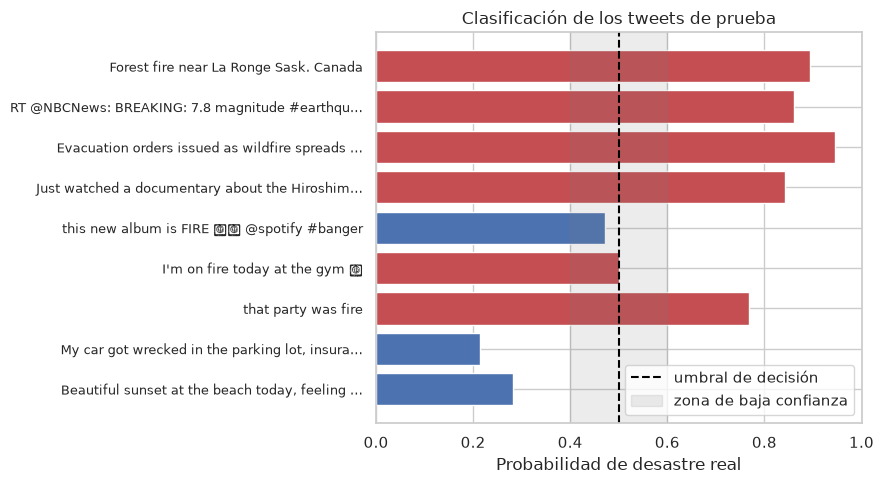

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
colores = ['#C44E52' if p >= 0.5 else '#4C72B0' for p in tabla['probabilidad']]
etiquetas = [t[:45] + '…' if len(t) > 45 else t for t in tabla['tweet']]

ax.barh(range(len(tabla)), tabla['probabilidad'], color=colores)
ax.set_yticks(range(len(tabla)))
ax.set_yticklabels(etiquetas, fontsize=9)
ax.axvline(0.5, color='black', ls='--', lw=1.5, label='umbral de decisión')
ax.axvspan(0.4, 0.6, color='gray', alpha=0.15, label='zona de baja confianza')
ax.set_xlim(0, 1)
ax.set_xlabel('Probabilidad de desastre real')
ax.set_title('Clasificación de los tweets de prueba')
ax.invert_yaxis()
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 3. Por qué decidió lo que decidió

El clasificador es lineal, así que la contribución de cada término es su valor TF-IDF
multiplicado por el coeficiente aprendido. Eso permite descomponer cualquier predicción en
los términos que la empujaron en cada dirección, sin recurrir a métodos de explicabilidad
externos.

In [5]:
for texto in [casos[0], casos[4], casos[6]]:
    r = clasificar_tweet(texto, modelo=modelo)
    print(f'\n{texto}')
    print(f'  → {r["etiqueta"]} (p = {r["probabilidad"]:.3f})')
    for termino, peso in explicar_prediccion(texto, top_n=5, modelo=modelo):
        direccion = 'desastre' if peso > 0 else 'no desastre'
        print(f'    {termino:22s} {peso:+.3f}  → {direccion}')


Forest fire near La Ronge Sask. Canada
  → Desastre real (p = 0.894)
    fire                   +0.623  → desastre
    near                   +0.518  → desastre
    forest                 +0.430  → desastre
    la                     +0.306  → desastre
    forest fire            +0.191  → desastre

this new album is FIRE 🔥🔥 @spotify #banger
  → No desastre (p = 0.471)
    fire                   +1.336  → desastre
    new                    -0.792  → no desastre
    album                  -0.282  → no desastre
    new album              -0.043  → no desastre

that party was fire
  → Desastre real (p = 0.768)
    fire                   +2.102  → desastre
    party                  -0.572  → no desastre


## 4. Dónde falla

Tres de los nueve casos merecen atención, y los tres son el mismo problema.

**`this new album is FIRE`** se clasifica bien como no-desastre, pero con probabilidad
0.471: apenas por debajo del umbral. La palabra `fire` aporta +1.34 y por sí sola bastaría
para cruzar la línea; lo que salva la predicción es que `new` y `album` arrastran en
sentido contrario.

**`I'm on fire today at the gym`** ya falla, aunque por poco: sale 0.500040, cuatro
diezmilésimas por encima del umbral. `fire` aporta +1.18 e `im` compensa con -0.93, pero
no alcanza.

**`that party was fire`** falla de forma contundente: 0.768. Al quedar reducido a dos
palabras tras la limpieza, `fire` (+2.10) solo encuentra a `party` (-0.57) enfrente.

El patrón que forman los tres es claro: **mientras más corto es el tweet metafórico, peor
falla**. La limpieza deja pocos términos, y si uno de ellos carga un coeficiente alto, no
queda nada que lo contrapese. Es la contracara del hallazgo del inciso 6 sobre los tweets
cortos, ahora visible como modo de falla concreto.

La raíz es que un modelo de bolsa de palabras no distingue el sentido literal del figurado:
no modela la relación entre `fire` y `gym` o entre `fire` y `party`, solo suma pesos
independientes. Es también la razón de que el clasificador marque estos casos con confianza
`baja` cuando la probabilidad queda a menos de 0.10 del umbral: conviene que quien consuma
la predicción sepa que se apoya en un margen estrecho. El caso de `party`, sin embargo,
muestra el límite de esa salvaguarda, porque falla con 0.768 y confianza alta.

El análisis de sentimiento del siguiente ejercicio puede aportar justamente la señal que
aquí falta: un tweet de desastre real y uno que usa `fire` como elogio tienen cargas
emocionales opuestas.

## 5. Comprobación del alineamiento

Toda la construcción descansa en que el tweet crudo termine representado igual que en el
entrenamiento. Lo verificamos de la forma más directa posible: pasamos los **1,523 tweets
crudos** del conjunto de prueba por la función completa y comparamos contra las métricas que
el notebook de modelos obtuvo sobre texto ya limpio.

Si los números coinciden, la limpieza y la vectorización de la función son idénticas a las
del entrenamiento. Si difieren, hay una desalineación en algún punto del camino.

In [6]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from src.modelos import split_data

raw = pd.read_csv('../data/raw/train.csv')
clean = pd.read_csv('../data/cleaned/train_cleaned.csv')

_, X_test, _, y_test = split_data(clean)
tweets_crudos = raw.loc[X_test.index, 'text']

predicciones = [clasificar_tweet(t, modelo=modelo)['es_desastre'] for t in tweets_crudos]
indeterminados = sum(1 for p in predicciones if p is None)
predicciones = [False if p is None else p for p in predicciones]

print(f'Tweets crudos evaluados : {len(predicciones)}')
print(f'Indeterminados          : {indeterminados}')
print(f'\nAccuracy end-to-end     : {accuracy_score(y_test, predicciones):.4f}')
print(f'F1 end-to-end           : {f1_score(y_test, predicciones):.4f}')
print(f'\nReportado en el inciso 6: accuracy 0.8050 / F1 0.7692')

Tweets crudos evaluados : 1523
Indeterminados          : 0

Accuracy end-to-end     : 0.8050
F1 end-to-end           : 0.7692

Reportado en el inciso 6: accuracy 0.8050 / F1 0.7692


Coinciden hasta el cuarto decimal. La función reproduce el desempeño del modelo partiendo de
texto sin preprocesar, que era exactamente lo que había que demostrar.

## 6. Casos límite

Un tweet formado únicamente por un enlace y emojis queda vacío después de la limpieza. El
vector TF-IDF resultante es nulo y el modelo respondería con su sesgo: una predicción sin
ninguna evidencia detrás, indistinguible en apariencia de una bien fundada.

Preferimos devolver `Indeterminado` de forma explícita antes que emitir un número que
aparenta significar algo. Las entradas inválidas (vacías o de tipo incorrecto) sí levantan
excepción, porque ahí el problema es de quien llama a la función, no del contenido.

In [7]:
print('Tweet que se vacía tras la limpieza:')
r = clasificar_tweet('https://t.co/abc123 🔥😱')
print(f'  {r["etiqueta"]} — {r["nota"]}\n')

print('Entradas inválidas:')
for entrada in ['', '   ', None]:
    try:
        clasificar_tweet(entrada)
        print(f'  {entrada!r}: no levantó excepción')
    except ValueError as e:
        print(f'  {entrada!r}: ValueError — {e}')

print('\nProcesamiento por lotes (el modelo se carga una sola vez):')
for r in clasificar_lote(['Massive flooding downtown', 'lol this is so funny', '']):
    print(f'  {r["etiqueta"]:14s} ← {r["texto_original"]!r}')

Tweet que se vacía tras la limpieza:
  Indeterminado — El tweet quedó vacío tras la limpieza: no contiene términos evaluables.

Entradas inválidas:
  '': ValueError — El texto del tweet no puede estar vacío.
  '   ': ValueError — El texto del tweet no puede estar vacío.
  None: ValueError — El texto del tweet no puede estar vacío.

Procesamiento por lotes (el modelo se carga una sola vez):
  Desastre real  ← 'Massive flooding downtown'
  No desastre    ← 'lol this is so funny'
  Error          ← ''


## 7. Modo interactivo

Además de la API, el módulo se puede ejecutar directamente para clasificar tweets desde la
terminal, que es la forma más cercana a lo que pide el enunciado:

```bash
python src/clasificador.py "Massive earthquake hits the city"
```

Sin argumentos entra en modo interactivo y va pidiendo tweets hasta que se escriba `salir`.
La celda siguiente hace lo mismo dentro del notebook; está comentada porque `input()` deja
el notebook esperando y eso impide ejecutarlo de corrido.

In [8]:
# from src.clasificador import main
# main()

## 8. Conclusiones

- La función recibe tweets crudos y reutiliza el pipeline de limpieza del entrenamiento
  desde una única definición compartida, de modo que ambos no puedan divergir.
- El desempeño end-to-end sobre los 1,523 tweets de prueba coincide exactamente con el
  reportado por el modelo (accuracy 0.805, F1 0.769), lo que confirma que no hay pérdida
  entre el texto crudo y la representación con que se entrenó.
- Cada predicción es explicable término por término, gracias a que el clasificador es lineal.
- Las predicciones cercanas al umbral se marcan con confianza `baja`, y los tweets que
  quedan vacíos tras la limpieza se reportan como `Indeterminado` en lugar de forzar una
  etiqueta.
- El punto débil sigue siendo el lenguaje figurado: `fire` referido a música o al gimnasio
  se acerca peligrosamente al umbral, y en uno de los dos casos lo cruza.